# Robin Marte – Final Project
For my final project, I am looking at how the overall stock market and oil moved around Operation Epic Fury and the wider Iran conflict period. I want to see whether a major real-world event like this showed up in the market and in oil prices in a noticeable way.

I'll be using two different sources here. I'll use Reuters coverage to help set the event window, and I'll use Federal Reserve Economic Data data for the S&P 500 and WTI crude oil series.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

## Loading the data

I'll load the two daily series directly from FRED and then combine them by date.

In [2]:
sp500_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=SP500"
oil_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILWTICO"

sp500 = pd.read_csv(sp500_url)
oil = pd.read_csv(oil_url)

sp500.columns = ["date", "sp500"]
oil.columns = ["date", "wti"]

sp500["date"] = pd.to_datetime(sp500["date"])
oil["date"] = pd.to_datetime(oil["date"])

sp500["sp500"] = pd.to_numeric(sp500["sp500"], errors="coerce")
oil["wti"] = pd.to_numeric(oil["wti"], errors="coerce")

market = pd.merge(sp500, oil, on="date", how="inner")
market = market.dropna(subset=["sp500", "wti"]).copy()
market = market.sort_values("date").reset_index(drop=True)

market.head()

,date,sp500,wti
0,2016-05-16,2066.66,47.72
1,2016-05-17,2047.21,48.29
2,2016-05-18,2047.63,48.12
3,2016-05-19,2040.04,48.16
4,2016-05-20,2052.32,47.67


## Event window

I'll use a window of about 45 days before and after the event so the trend is easier to see.

One challenge I'll handle is that the event date falls on a weekend, so I'll compare trading days before and after the event instead of trying to use the exact calendar day.

In [3]:
event_date = pd.Timestamp("2026-02-28")
window_start = event_date - pd.Timedelta(days=45)
window_end = event_date + pd.Timedelta(days=45)

market = market[(market["date"] >= window_start) & (market["date"] <= window_end)].copy()
market = market.sort_values("date").reset_index(drop=True)

market["days_from_event"] = (market["date"] - event_date).dt.days
market["period"] = np.where(market["days_from_event"] < 0, "Before", "After")
market["period"] = pd.Categorical(market["period"], categories=["Before", "After"], ordered=True)

market.head()

,date,sp500,wti,days_from_event,period
0,2026-01-14,6926.60,61.84,-45,Before
1,2026-01-15,6944.47,59.13,-44,Before
2,2026-01-16,6940.01,59.40,-43,Before
3,2026-01-20,6796.86,60.30,-39,Before
4,2026-01-21,6875.62,60.38,-38,Before


## Transforming the data

I'll calculate daily percentage returns and normalize both series so they can be compared on the same scale.

In [4]:
market["sp500_ret"] = market["sp500"].pct_change()
market["wti_ret"] = market["wti"].pct_change()

market["sp500_abs_ret"] = market["sp500_ret"].abs()
market["wti_abs_ret"] = market["wti_ret"].abs()

market["sp500_norm"] = market["sp500"] / market["sp500"].iloc[0] * 100
market["wti_norm"] = market["wti"] / market["wti"].iloc[0] * 100

returns = market.dropna(subset=["sp500_ret", "wti_ret"]).copy()

returns.head()

,date,sp500,wti,days_from_event,period,sp500_ret,wti_ret,sp500_abs_ret,wti_abs_ret,sp500_norm,wti_norm
1,2026-01-15,6944.47,59.13,-44,Before,0.002580,-0.043823,0.002580,0.043823,100.257991,95.617723
2,2026-01-16,6940.01,59.40,-43,Before,-0.000642,0.004566,0.000642,0.004566,100.193601,96.054334
3,2026-01-20,6796.86,60.30,-39,Before,-0.020627,0.015152,0.020627,0.015152,98.126931,97.509702
4,2026-01-21,6875.62,60.38,-38,Before,0.011588,0.001327,0.011588,0.001327,99.263997,97.639069
5,2026-01-22,6913.35,59.24,-37,Before,0.005488,-0.018880,0.005488,0.018880,99.808708,95.795602


## Grouping the results

I'll group the data into before and after the event so I can compare the average returns and average movement in each period.

In [5]:
summary = returns.groupby("period").agg(
    sp500_avg_return=("sp500_ret", "mean"),
    wti_avg_return=("wti_ret", "mean"),
    sp500_avg_abs_return=("sp500_abs_ret", "mean"),
    wti_avg_abs_return=("wti_abs_ret", "mean"),
    sp500_volatility=("sp500_ret", "std"),
    wti_volatility=("wti_ret", "std")
)

summary.round(6)

/tmp/ipykernel_17519/882099221.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = returns.groupby("period").agg(


,sp500_avg_return,wti_avg_return,sp500_avg_abs_return,wti_avg_abs_return,sp500_volatility,wti_volatility
period,,,,,,
Before,-0.000198,0.002878,0.006109,0.016606,0.008238,0.021436
After,0.000474,0.012653,0.008672,0.048564,0.011298,0.063079


## What I notice from the summary table

This table makes the before and after comparison easier to read.

What stands out to me is that the S&P 500 barely changes between the two periods, while WTI oil gets much more volatile after the event. The average absolute return for oil goes from 0.016606 before to 0.048564 after, which is a pretty big jump.

The S&P 500 average absolute return also rises a little, from 0.006109 to 0.008672, but that change is much smaller. The average return for the S&P 500 stays close to zero in both periods, while oil shows a stronger positive average return after the event.

That makes it look like the event shows up much more clearly in oil than in the broad market.

## Statistical test

I'll use a simple t-test to compare the average absolute daily returns before and after the event.

This will help me check whether the amount of daily movement changes in a meaningful way.

In [6]:
before = returns[returns["period"] == "Before"]
after = returns[returns["period"] == "After"]

sp500_test = ttest_ind(
    before["sp500_abs_ret"],
    after["sp500_abs_ret"],
    equal_var=False,
    nan_policy="omit"
)

wti_test = ttest_ind(
    before["wti_abs_ret"],
    after["wti_abs_ret"],
    equal_var=False,
    nan_policy="omit"
)

print("SP500 t-test:", sp500_test)
print("WTI t-test:", wti_test)

SP500 t-test: TtestResult(statistic=np.float64(-1.5914921164749969), pvalue=np.float64(0.11712579196501885), df=np.float64(56.02908650012909))
WTI t-test: TtestResult(statistic=np.float64(-4.0862142514419215), pvalue=np.float64(0.00022970353859091977), df=np.float64(36.54332352955642))


## What I notice from the t-test

The S&P 500 p-value is 0.117, so I would not call that a strong statistical change in movement before and after the event. WTI oil is different though, because the p-value is 0.0002297, which is very small.

That tells me the change in oil movement after the event looks meaningful, while the change in the S&P 500 does not look nearly as strong.

## Graphic 1: normalized market and oil prices

I'll use this chart to compare both series on the same scale around the event window.

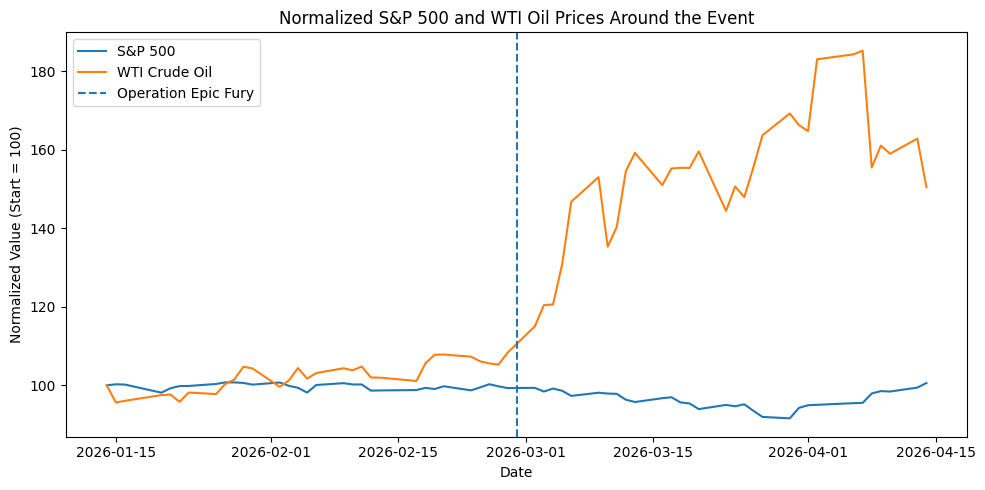

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(market["date"], market["sp500_norm"], label="S&P 500")
plt.plot(market["date"], market["wti_norm"], label="WTI Crude Oil")
plt.axvline(event_date, linestyle="--", label="Operation Epic Fury")
plt.title("Normalized S&P 500 and WTI Oil Prices Around the Event")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Start = 100)")
plt.legend()
plt.tight_layout()
plt.show()

## What I notice from the line chart

This chart makes it easier to compare the two series on the same scale.

What stands out is that the S&P 500 stays fairly close to its starting point for most of the window and only dips a little after the event before recovering near the end. WTI does the opposite and jumps sharply after the event, then stays at a much higher level for most of the rest of the window.

So the line chart matches the summary table pretty well. The market looks relatively stable, but oil reacts much more strongly.

## Graphic 2: average daily movement before and after

I'll use this chart to compare the average absolute daily return before and after the event.

I'll use it as a simple way to look at volatility.

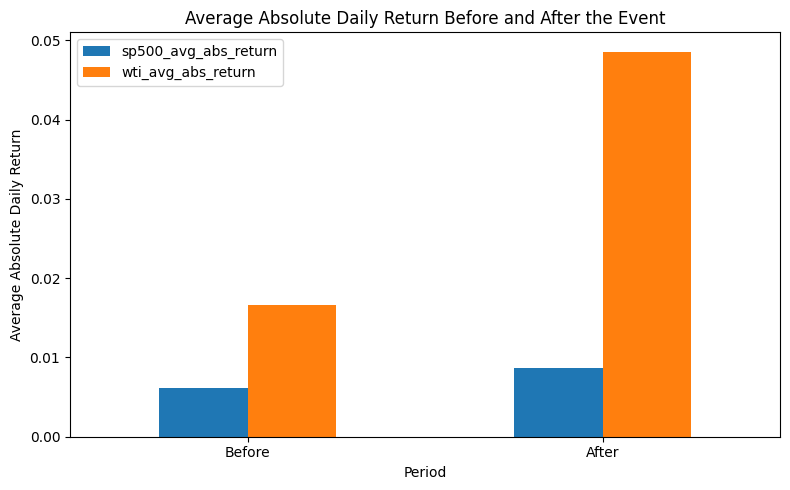

In [8]:
summary[["sp500_avg_abs_return", "wti_avg_abs_return"]].plot(kind="bar", figsize=(8, 5))
plt.title("Average Absolute Daily Return Before and After the Event")
plt.xlabel("Period")
plt.ylabel("Average Absolute Daily Return")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## What I notice from the bar chart

This chart shows the difference between the before and after periods even more clearly.

The after-event bar is higher for both series, but oil’s increase is much bigger. That lines up with the line chart and the t-test, since the oil series looks like it was affected more than the broad market.

This also makes me think the event had a much stronger effect on oil than on the overall market.

## Conclusion

This project helped me look at how the overall stock market and oil moved around the late-February 2026 Iran conflict period. By pulling the data together, normalizing both series, and comparing the before and after window, I was able to look at the market in a simple but organized way.

The charts, grouped summary, and t-test gave me a few different ways to check whether the event lined up with a noticeable change in movement. One thing I had to work around was that the event date fell on a weekend, so I used nearby trading days instead of the exact calendar day.

Overall, this project showed me that the broad market stayed fairly stable, while oil moved much more strongly around the event.